In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from collections import defaultdict
from PIL import Image
from sklearn.model_selection import train_test_split
import shutil
import yaml


COMP_ROOT = Path("D:/local_files/Solar Filament Segmentation Challenge")
DATA_ROOT = COMP_ROOT / "MAGFiLO_1.0_Kaggle_2026"
JSON_PATH = DATA_ROOT / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
IMAGE_DIR = DATA_ROOT / "train" / "train_images"
TEST_DIR = DATA_ROOT / "test" / "test_images"

CURRENT_ROOT = Path(r"D:\local_files\Solar Filament Segmentation Challenge\yolo-segmentation")
YOLO_ROOT = CURRENT_ROOT / "dataset"
RUNS = CURRENT_ROOT / "runs"

height = width = 2048
print(len(list(IMAGE_DIR.glob("*.jpeg"))))

707


In [3]:
coco_data = json.loads(JSON_PATH.read_text(encoding = "utf-8"))
id_to_image ={im['id']:im for im in coco_data['images']}

In [4]:
anns_by_image_id = defaultdict(list)
for ann in coco_data['annotations']:
    anns_by_image_id[ann['image_id']].append(ann)

In [5]:
len(anns_by_image_id), len(id_to_image)

(1154, 1154)

In [6]:
file_to_image_ids =defaultdict(list)
for im in coco_data['images']:
    file_to_image_ids[im['file_name']].append(im['id'])

In [7]:
files = np.array(sorted(file_to_image_ids.keys()))
train_files, val_files = train_test_split(files, test_size = 0.15, random_state = 42)
len(train_files), len(val_files)

(600, 107)

In [8]:
from skimage.draw import polygon as draw_polygon

def polygon_to_mask(segmentation, height = height, width = width):
    mask = np.zeros((height, width), dtype = np.uint8)
    for poly in segmentation:
        xy = np.asarray(poly, dtype = np.float32).reshape(-1,2)
        rows, cols = draw_polygon(xy[:,1], xy[:, 0], shape = (height, width))
        mask[rows, cols] = 1
    return mask
def instance_mask(annotations, height = height, width = width):
    return np.stack([polygon_to_mask(a['segmentation'], height, width) for a in annotations], axis = 0) if annotations else np.zeros((0, height, width), dtype = np.uint8)


In [10]:
for split in ["train", "val"]:
    (YOLO_ROOT/"images"/split).mkdir(parents = True, exist_ok = True)
    (YOLO_ROOT/"labels"/split).mkdir(parents = True, exist_ok = True)


In [ ]:
def polygon_to_yolo_line(segmentation, cls = 0):
    parts = []
    for poly in segmentation:
        xy = np.asarray(poly, dtype = np.float32).reshape(-1, 2)
        xy[:, 0] = np.clip(xy[:, 0]/ width, 0, 1)
        xy[:, 1] = np.clip(xy[:, 1]/ height, 0, 1)
        if len(xy) < 3:
            continue
        parts.extend([f"{x:.6f} {y:.6f}" for x, y in xy])
    if not parts:
        return None
    return f"{cls} " + " ".join(parts)


def export_split(file_list, split):
    n_obj = 0
    for fn in file_list:
        fn = str(fn)
        src = IMAGE_DIR / fn
        dst = YOLO_ROOT / "images" / split / fn
        if not src.exists():
            raise FileNotFoundError(src)
        if not dst.exists():
            try:
                dst.hardlink_to(src)
            except OSError:
                shutil.copy2(src, dst)
        image_id = file_to_image_ids[fn][0]
        lines = []
        for a in anns_by_image_id[image_id]:
            line = polygon_to_yolo_line(a["segmentation"])
            if line:
                lines.append(line)
                n_obj += 1
        stem = Path(fn).stem
        (YOLO_ROOT / "labels" / split / f"{stem}.txt").write_text(
            "\n".join(lines) + ("\n" if lines else ""),
            encoding="utf-8",
        )
    return n_obj
print("train objects", export_split(train_files, "train"))
print("val objects", export_split(val_files, "val"))
yaml_path = YOLO_ROOT / "data.yaml"
yaml_path.write_text(
    yaml.dump(
        {
            "path": str(YOLO_ROOT).replace("\\", "/"),
            "train": "images/train",
            "val": "images/val",
            "names": {0: "filament"},
        },
        sort_keys=False,
    ),
    encoding="utf-8",
)
print("wrote", yaml_path)

In [22]:
from ultralytics import YOLO
model = YOLO("yolo11s-seg.pt")

train_res = model.train(
    data = str(YOLO_ROOT / "data.yaml"),
    epochs = 20,
    imgsz = 1024,
    batch = 2,
    device = 0,
    workers = 2,
    project = str(RUNS),
    name = "sseg_1024",
    exist_ok = True,
    patience = 5,
    lr0 = 0.01,
    seed = 42,
    plots = True,
    mosaic=0.0
)
print("best", RUNS / "sseg_1024" / "weights" / "best.pt")

Ultralytics 8.4.155  Python-3.12.13 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\local_files\Solar Filament Segmentation Challenge\yolo-segmentation\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0

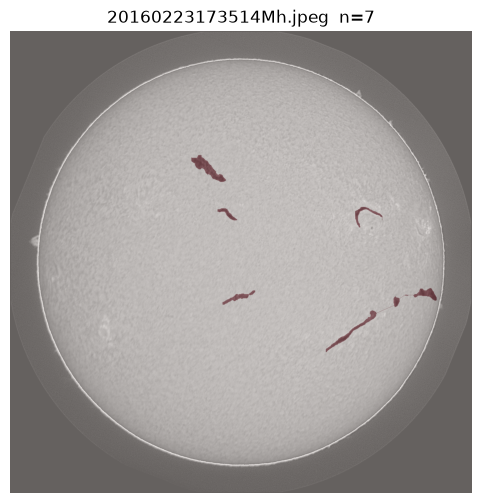

In [26]:
import cv2
import matplotlib.pyplot as plt

WEIGHTS = RUNS/"sseg_1024"/"weights"/"best.pt"

yolo = YOLO(str(WEIGHTS))

def yolo_instances(image_path, conf = 0.25, min_area = 500):
    pred = yolo.predict(source = str(image_path), imgsz = 1024, conf = conf, iou = 0.7, verbose = False)[0]
    inst = []
    if pred.masks is None:
        return inst
    for poly in pred.masks.xy:
        m = np.zeros((height, width), dtype = np.uint8)
        pts = np.round(poly).astype(np.int32)
        if len(pts) >= 3:
            cv2.fillPoly(m, [pts], 1)
            if m.sum() >= min_area:
                inst.append(m.astype(bool))
    return inst

fn = str(val_files[0])
gray = np.array(Image.open(IMAGE_DIR/fn).convert("L"))
inst = yolo_instances(IMAGE_DIR/fn, conf = 0.25)
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
if inst:
    plt.imshow(np.any(inst, axis=0), cmap="Reds", alpha=0.4)
plt.title(f"{fn}  n={len(inst)}")
plt.axis("off")
plt.show()

In [27]:
def to_bool_list(masks):
    return [np.asarray(m).astype(bool) for m in masks if np.asarray(m).any()]

def iou_dice(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    s = a.sum() + b.sum()
    iou = float(inter / union) if union else 0.0
    dice = float(2 * inter / s) if s else 1.0
    return iou, dice

def iou_matrix(gt_masks, pred_masks):
    M = np.zeros((len(gt_masks), len(pred_masks)), dtype=np.float32)
    for i, g in enumerate(gt_masks):
        for j, p in enumerate(pred_masks):
            M[i, j], _ = iou_dice(g, p)
    return M

def match_at_half(M):
    pairs = [(float(M[i, j]), i, j) for i in range(M.shape[0]) for j in range(M.shape[1]) if M[i, j] >= 0.5]
    pairs.sort(reverse=True)
    used_g, used_p, matches = set(), set(), []
    for v, i, j in pairs:
        if i in used_g or j in used_p:
            continue
        used_g.add(i)
        used_p.add(j)
        matches.append((i, j, v))
    return matches

def panoptic_from_match(n_gt, n_pred, matches, ious):
    tp = len(matches)
    fp = n_pred - tp
    fn = n_gt - tp
    den = tp + 0.5 * fp + 0.5 * fn
    pq = (sum(ious) / den) if den else (1.0 if n_gt == n_pred == 0 else 0.0)
    return pq, tp, fp, fn

def evaluate_yolo(file_name, conf=0.25, min_area=500):
    pred = yolo_instances(IMAGE_DIR / file_name, conf=conf, min_area=min_area)
    image_id = file_to_image_ids[file_name][0]
    gt = [m.astype(bool) for m in instance_mask(anns_by_image_id[image_id])]
    gt = to_bool_list(gt)
    pred = to_bool_list(pred)
    if not gt and not pred:
        return {"pq": 1.0, "n_gt": 0, "n_pred": 0, "tp": 0, "fp": 0, "fn": 0}
    M = iou_matrix(gt, pred) if (gt and pred) else np.zeros((len(gt), 0))
    matches = match_at_half(M) if M.size else []
    pq, tp, fp, fn = panoptic_from_match(len(gt), len(pred), matches, [m[2] for m in matches])
    return {"pq": pq, "n_gt": len(gt), "n_pred": len(pred), "tp": tp, "fp": fp, "fn": fn}

In [28]:
from tqdm.auto import tqdm

files20 = list(map(str, val_files[:20]))
for conf in [0.15, 0.25, 0.35, 0.50]:
    part = [evaluate_yolo(fn, conf=conf) for fn in files20]
    print(
        "conf", conf,
        "PQ", round(np.mean([r["pq"] for r in part]), 3),
        "pred", round(np.mean([r["n_pred"] for r in part]), 1),
        "gt", round(np.mean([r["n_gt"] for r in part]), 1),
    )

conf 0.15 PQ 0.291 pred 12.8 gt 6.4
conf 0.25 PQ 0.336 pred 8.8 gt 6.4
conf 0.35 PQ 0.351 pred 7.0 gt 6.4
conf 0.5 PQ 0.364 pred 4.3 gt 6.4


In [30]:
BEST_CONF = 0.35  # set to the best PQ row
rows = [evaluate_yolo(str(fn), conf=BEST_CONF) for fn in tqdm(list(map(str, val_files)))]
print("YOLO val PQ", np.mean([r["pq"] for r in rows]))
print("U-Net val PQ was 0.38; public 0.33")

  0%|          | 0/107 [00:00<?, ?it/s]

YOLO val PQ 0.32695991916092004
U-Net val PQ was 0.38; public 0.33
